# Running the pipeline locally

An illustration, not new machinery. Every cell calls one verb from
`spikesorting.pipeline` -- the same verbs the two runner scripts call, in the same
order. The notebook only adds the explanation between them and lets you look at what
each step returns, which the scripts do not.

The command line equivalent, in the two passes the real workflow uses. Curation in Phy
sits between them, which is why there are two scripts and not one:

```bash
python run_sorting_pipeline.py   --config configs/demo.yaml
# ... curate in Phy ...
python run_exporting_pipeline.py --config configs/demo.yaml
```

**What runs where.** Sync extraction, remapping, export and plotting need only NumPy
and SciPy, so they run anywhere. Loading needs SpikeInterface. Sorting needs the
`kilosort4` environment with a CUDA build of torch; those cells report and move on when
it is absent.

**Verbs return values, not status objects** -- a recording, a report, a map -- so each
cell below shows the real thing. A verb returns `None` when the session config says not
to do that work, and `None` propagates, so the sequence needs no branching.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import spikesorting as ss

print(REPO)
print("verbs:", ", ".join(n for n in ss.__all__ if n[0].islower()))

/Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Program_Python/SpikeSortingKilosort
verbs: skip_reason, load_session_config, setup_probe, load_spike_continuous, preprocess, sort_with_kilosort, extract_sync, extract_lfp, time_remapping, validate_remapping, export_results, load_machine


## 1. Load the session configuration

**This step loads no data.** It reads the two YAML layers -- the session says *what was
recorded* (portable), the machine says *where this computer keeps things* -- and
resolves them into one `SessionConfig`. The same session file runs on the rig, the HPC
and here.

`configs/demo.yaml` is an ordinary session config: it points at the demo binary and
declares which systems recorded. Nothing branches on it being "the demo".

In [2]:
config = ss.load_session_config(REPO / "configs" / "demo.yaml", "windows_rig")
config.paths.mkdirs()

print(f"session:   {config.session}")
print(f"machine:   {config.machine.name}  (device={config.machine.device})")
print(f"cache:     {config.cache_dir}")
print(f"CatGT:     {config.machine.catgt_dir or 'not installed -> NumPy fallback'}")
print(f"TPrime:    {config.machine.tprime_dir or 'not installed -> least-squares fit'}")

# Outputs sit beside the recording that produced them, so there are up to two trees.
for system in ("blackrock", "neuropixels"):
    directory = config.paths.dir_for(system)
    print(f"{system + ':':13}{directory if directory else 'did not record'}")

# Two questions per system: did it record, and should it be sorted.
print(
    f"\nneuropixels: data={config.has_neuropixels_data} sorts={config.sorts_neuropixels}\n"
    f"blackrock:   data={config.has_blackrock_data} sorts={config.sorts_blackrock}\n"
    f"skip_sync={config.skip_sync} (cross-system alignment)"
)

problems = config.missing_inputs()
print("\ninputs OK" if not problems else "\n" + "\n".join(f"MISSING: {p}" for p in problems))


session:   demo
machine:   windows_rig  (device=cuda)
cache:     D:/kilosort_cache
CatGT:     C:/SpikeGLX/CommandLineTools/CatGTWinApp/CatGT-win
TPrime:    C:/SpikeGLX/CommandLineTools/TPrimeWinApp/TPrime-win
blackrock:   did not record
neuropixels: /Users/xuefeiyu/ephys/demo_data

neuropixels: data=True sorts=True
blackrock:   data=False sorts=False
skip_sync=True (cross-system alignment)

inputs OK


## 2. Set up the probe

The channel map, as its own step rather than something hidden inside loading -- this is
where a wrong choice does the most damage, because units land on the wrong electrodes
and nothing downstream can tell.

Resolution order is the same for both systems: `probe_file` from the session, else the
run's `.meta` (Neuropixels) or the array's `.cmp` (Utah), else -- for Utah only -- a
placeholder grid that sorts but warns.

The demo is awkward here on purpose: its binary has no `.meta`, so `demo.yaml` names
Kilosort's `NeuroPix1_default.mat`, which only exists once Kilosort has downloaded it.
Off the sorting machine there is no map, so the cell falls back to an obviously
labelled demonstration geometry. It is **not** the real NP 1.0 map -- use it to watch
the plumbing, never to interpret a unit's position.

In [3]:
SYSTEM = "neuropixels"


def demo_probe(n_chan=384):
    """A stand-in map so the demo can load off the sorting machine.

    Two sites per 20 um row in two columns: the right *shape* for a linear probe and
    the wrong *geometry* for NP 1.0, which staggers four x positions.
    """
    return {
        "chanMap": np.arange(n_chan),
        "xc": np.tile([0.0, 32.0], n_chan // 2),
        "yc": np.repeat(np.arange(n_chan // 2) * 20.0, 2),
        "kcoords": np.zeros(n_chan),
        "n_chan": n_chan,
        "_placeholder": True,
    }


try:
    probe = ss.setup_probe(config, SYSTEM)
    print(f"map from the session config: {probe['n_chan']} channels")
except FileNotFoundError as error:
    print(f"no map available here -- {error}\n")
    print("falling back to a DEMONSTRATION geometry (not the real NP 1.0 map)")
    probe = demo_probe()

no map available here -- probe_name 'NeuroPix1_default.mat' not found at /Users/xuefeiyu/.kilosort/probes/NeuroPix1_default.mat. Kilosort ships these and downloads them on first use, so this needs the kilosort4 env. On a machine without it, set neuropixels.probe_file to a JSON built by tools/make_probe.py instead.

falling back to a DEMONSTRATION geometry (not the real NP 1.0 map)


## 3. Load the spike-band continuous data

`load_spike_continuous(config, system, probe)` returns a SpikeInterface `BaseRecording`
with the probe attached. Spike-band continuous data specifically -- not the LFP and not
the sync channels, which have verbs of their own.

Both systems return the same object, which is what lets every step after this stop
caring which one it came from.

In [4]:
try:
    recording = ss.load_spike_continuous(config, SYSTEM, probe)
    print(recording)
    print(f"\n{recording.get_num_channels()} channels @ "
          f"{recording.get_sampling_frequency():.0f} Hz, {recording.get_duration():.1f} s")
    print(f"probe: {recording.get_probe()}")
except ImportError as error:
    recording = None
    print(f"skipped, needs spikeinterface: {error}")

ChannelSliceRecording: 384 channels - 30.0kHz - 1 segments - 1,350,000 samples - 45.00s 
                       int16 dtype - 988.77 MiB

384 channels @ 30000 Hz, 45.0 s
probe: Probe - 384ch


## 4. Preprocess

Applies this system's `preprocess:` block, in order: bad-channel detection (which
*drops* channels), then bandpass, then the common reference. `common_reference` is
`"median"` (CMR), `"average"`/`"mean"` (CAR), or `null` for none.

Each system declares its own block, because the right answer differs -- Kilosort filters
and references internally, which is enough for a dense probe, while a 400 um Utah array
benefits from an explicit median reference.

Returns the recording unchanged when the block says `apply: false`, and `None` when
given `None`, so it is always safe to call.

In [5]:
from spikesorting._preprocess import describe_preprocessing, preprocess_recording

print("configured for this session:", config.preprocess_for(SYSTEM))

processed = ss.preprocess(recording, config, SYSTEM)
print("-> unchanged, apply is false\n" if processed is recording else f"-> {processed}\n")

# What a Utah-style block does to the same recording. Each call wraps and computes
# nothing: the filtering happens when Kilosort pulls samples.
if recording is not None:
    settings = describe_preprocessing(
        {"apply": True, "bandpass": [300, 6000], "common_reference": "median"}
    )
    settings.pop("apply")
    filtered, info = preprocess_recording(recording, **settings)
    print("with apply: true ->", filtered)
    print("what was applied:", info)

configured for this session: {'apply': False, 'bandpass': [300, 6000], 'common_reference': 'median'}
-> unchanged, apply is false



with apply: true -> CommonReferenceRecording: 384 channels - 30.0kHz - 1 segments - 1,350,000 samples - 45.00s 
                          int16 dtype - 988.77 MiB
what was applied: {'bandpass': [300.0, 6000.0], 'common_reference': 'median', 'bad_channel_ids': [], 'n_channels_out': 384}


## 5. Sort with Kilosort4

`sort_with_kilosort(recording, config, system)` takes the recording -- it does not load
one for itself, so the four steps above stay visible. Sorting runs in the machine's SSD
cache and the results are copied out, so `temp.dat` never touches the network share.

Returns `None` without sorting when `kilosort_on_<system>` is false: the "extract the
pulses and the LFP but do not sort" case.

This is the slow cell and the only one needing a GPU. On a real session run it from
`run_sorting_pipeline.py` so it survives a closed laptop, or send it to a cluster:

```bash
python run_sorting_pipeline.py --config configs/<s>.yaml --machine hpc --steps sort
```

In [6]:
print("will it sort?", ss.skip_reason(config, ss.sort_with_kilosort, SYSTEM) or "yes")

try:
    result = ss.sort_with_kilosort(processed, config, SYSTEM)
    print(f"{result.n_units} units -> {result.results_dir}" if result else "nothing to sort")
except Exception as error:
    print(f"cannot sort on this machine: {error}")

will it sort? yes
cannot sort on this machine: The sorter kilosort4 is not installed. Please install it with:

To use Kilosort4 run:

        >>> pip install kilosort --upgrade

    More information on Kilosort4 at:
        https://github.com/MouseLand/Kilosort
    


### The other system, same verbs

Nothing changes but the argument. The `.ns6` goes through SpikeInterface's
`read_blackrock` instead of `read_binary`, and the map comes from the array's `.cmp`
rather than the run's `.meta` -- but `load_spike_continuous` hides that, and
`preprocess` and `sort_with_kilosort` never learn which system they were given.

`skip_reason` is what the runner scripts print for a `[--]` line.

In [7]:
for system in ss.SYSTEMS:
    print(f"{system:12} data={getattr(config, f'has_{system}_data')} "
          f"sorts={getattr(config, f'sorts_{system}')} "
          f"-> {config.paths.dir_for(system)}")
    for verb in (ss.setup_probe, ss.load_spike_continuous, ss.sort_with_kilosort):
        why = ss.skip_reason(config, verb, system)
        print(f"    {verb.__name__:24} {why or 'will run'}")

neuropixels  data=True sorts=True -> /Users/xuefeiyu/ephys/demo_data
    setup_probe              will run
    load_spike_continuous    will run
    sort_with_kilosort       will run
blackrock    data=False sorts=False -> None
    setup_probe              has_blackrock_data is false
    load_spike_continuous    has_blackrock_data is false
    sort_with_kilosort       has_blackrock_data is false


## 6. Extract the sync pulses

Per system, into that system's own `sync/`. Runs CatGT where the machine has it, always
runs the NumPy detector, and compares them -- that agreement is what lets the fallback
be trusted on a machine without CatGT.

Each file is one leading-edge time in seconds per line: the format CatGT produces and
TPrime consumes.

In [8]:
report = ss.extract_sync(config, SYSTEM)
print(report.summary() if report else "nothing to extract")

npx_1hz: 44 edges via numpy spanning 43.0 s <- ZFM-02370_mini.imec0.ap.short.bin SY bit 6
       CatGT skipped: this session points at a bare .bin, and CatGT needs a SpikeGLX run (run_dir + run_name + _g<n>_t<n> naming).
       Neuropixels 14 s burst extraction skipped: no OneBox (obx) stream found.


Look at what came out. For a 1 Hz square wave the intervals should sit on 1.000 s with
jitter of about one sample (33 us at 30 kHz).

npx_1hz: 44 edges from numpy, span 43.0 s
    interval mean 1.000002 s, jitter 8.5 us


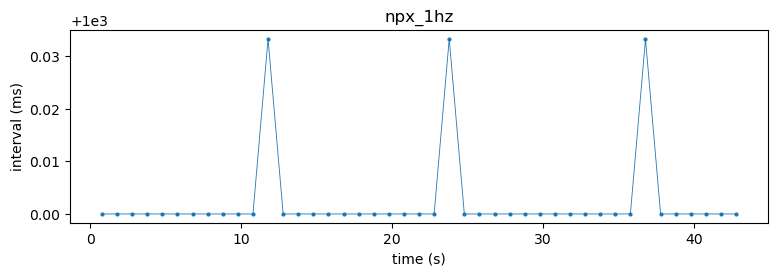

In [9]:
for name, edges in sorted((report.edge_sets if report else {}).items()):
    times = edges.times_s
    print(f"{name}: {edges.n} edges from {edges.source}, span {edges.span_s:.1f} s")
    if times.size > 2:
        intervals = np.diff(times)
        print(
            f"    interval mean {intervals.mean():.6f} s,"
            f" jitter {intervals.std() * 1e6:.1f} us"
        )
        figure, ax = plt.subplots(figsize=(9, 2.5), dpi=100)
        ax.plot(times[:-1], intervals * 1e3, ".-", markersize=4, linewidth=0.6)
        ax.set_xlabel("time (s)")
        ax.set_ylabel("interval (ms)")
        ax.set_title(name)
        plt.show()

A run with no pulses reports zero edges rather than failing — that is the correct
result for a recording made without SMA1 connected. Check `result.notes`; it also
records the CatGT command that *would* have run, so a rig run can be reproduced by hand.

## 6. Curate in Phy

Not scriptable, and not meant to be:
```bash
conda activate phy
```

```bash
phy template-gui <output>/neuropixels/kilosort4/params.py
```

Phy writes `cluster_group.tsv`, whose labels override Kilosort's own
`cluster_KSLabel.tsv`. Everything downstream reads the human labels when they exist.

## 7. Map onto the Blackrock timebase

`time_remapping(config, system)` maps `system` onto Blackrock. Blackrock is the
reference, so it is not an argument -- and asking to remap Blackrock itself returns
`None`, since there is nothing to map the reference onto.

1. coarse offset from the 14 s coded bursts (which resolve *which* 1 Hz cycle);
2. both 1 Hz trains trimmed to their overlapping window;
3. fine fit via TPrime, or least squares on the same matched edges;
4. `validate_remapping` checks it against the burst onsets, held out of the fit.

Skipped for the demo: there is no second system.

In [10]:
print(ss.time_remapping(config, "neuropixels") or "no remapping for this session")
print(ss.validate_remapping(config) or "no validation for this session")

no remapping for this session
no validation for this session


The pure-compute pieces are worth knowing individually — they take arrays and return
arrays, so you can drive them on your own edge lists without any config at all.

Below, two synthetic systems: SpikeGLX starts 137.5 s later on its own clock and runs
30 ppm fast. Note the order — the **coded burst** supplies the coarse offset, and only
then is the 1 Hz train used. Doing it the other way round does not work, for a reason
worth seeing (two cells down).

In [11]:
from spikesorting._sync import align, burst

OFFSET, DRIFT = 137.5, 30e-6
rng = np.random.default_rng(0)


def coded_bursts(n, interval=14.0, pulses=8, gap=0.02):
    """Dense bursts every `interval` s, each with its own intra-burst pattern."""
    times = []
    for i in range(n):
        onset = i * interval
        times.append(onset)
        times.extend(onset + np.cumsum(gap * (1 + rng.uniform(0, 1, pulses - 1))))
    return np.sort(np.asarray(times))


to_spikeglx = lambda t: (t - OFFSET) / (1 + DRIFT)

blackrock_1hz = np.arange(0.0, 1200.0, 1.0)
blackrock_burst = coded_bursts(int(1200 // 14))
# SpikeGLX started late, so it missed the first 200 s that Blackrock caught.
spikeglx_1hz = to_spikeglx(blackrock_1hz[blackrock_1hz >= 200.0])
spikeglx_burst = to_spikeglx(blackrock_burst[blackrock_burst >= 200.0])

# 1. Coarse offset from the coded burst.
match = burst.match_bursts(blackrock_burst, spikeglx_burst, min_gap_s=7.0, tolerance_s=0.05)
print(f"coarse offset : {match.offset_s:.6f} s  (planted {OFFSET})")
print(f"                {match.n_matched} bursts matched, "
      f"pulse score {match.pulse_score} vs runner-up {match.runner_up_score}")

# 2. Trim both 1 Hz trains to the overlapping window, then 3. fit the fine map.
br_trim, npx_trim = align.trim_pair_to_overlap(
    blackrock_1hz, spikeglx_1hz, match.offset_s, margin_s=0.25
)
ref_idx, other_idx = burst.match_times(br_trim, npx_trim, match.offset_s, tolerance_s=0.25)
mapping = align.fit_linear_map(npx_trim[other_idx], br_trim[ref_idx])

print(f"matched edges : {mapping.n_points}")
print(f"slope         : {mapping.slope:.9f}  ({mapping.drift_ppm:+.2f} ppm)")
print(f"intercept     : {mapping.intercept:.6f} s  (planted {OFFSET})")
print(f"fit residual  : {np.abs(mapping.residuals_s).max() * 1e6:.3f} us max")

coarse offset : 137.516825 s  (planted 137.5)
                70 bursts matched, pulse score 535 vs runner-up 498
matched edges : 998
slope         : 1.000030000  (+30.00 ppm)
intercept     : 137.500000 s  (planted 137.5)
fit residual  : 0.000 us max


### Why the burst has to come first

A 1 Hz square wave is *periodic*, so every whole-second shift fits it equally well.
Asking `estimate_offset` for the offset from the 1 Hz train alone returns the
maximum-overlap alignment, which is off by a whole number of cycles — and because the
subsequent fit is self-consistent with that wrong offset, it looks fine right up until
validation. The coded burst is what breaks the tie.

In [12]:
naive = burst.estimate_offset(blackrock_1hz, spikeglx_1hz, tolerance_s=0.1)
print(f"from the 1 Hz train alone : {naive:10.3f} s   <- wrong by whole cycles")
print(f"from the coded burst      : {match.offset_s:10.3f} s   <- correct")
print(f"planted                   : {OFFSET:10.3f} s")

from the 1 Hz train alone :    -62.483 s   <- wrong by whole cycles
from the coded burst      :    137.517 s   <- correct
planted                   :    137.500 s


### Step 9: validation on held-out bursts

The map was fit on the 1 Hz train, so the burst onsets are held-out data — which is
what makes this a real check rather than a restatement of the fit.

Ignoring the slope is the classic mistake: at 30 ppm the error reaches ~100 ms after an
hour, so an offset-only alignment sails through a quick eyeball and fails step 9.

In [13]:
br_onsets = burst.group_burst_onsets(blackrock_burst, 7.0)
npx_onsets = burst.group_burst_onsets(spikeglx_burst, 7.0)

offset_only = align.LinearMap(slope=1.0, intercept=OFFSET, n_points=2, residuals_s=np.empty(0))

for label, candidate in [("offset + slope", mapping), ("offset only", offset_only)]:
    report = align.validate_alignment(
        candidate.apply(npx_onsets), br_onsets, tolerance_s=1e-3, match_tolerance_s=1.0
    )
    print(f"{label:>16}: {report.summary()}")

  offset + slope: alignment PASS: 70 bursts checked, max |residual| 0.000 ms, median 0.000 ms (tolerance 1.000 ms)
     offset only: alignment FAIL: 70 bursts checked, max |residual| 31.154 ms, median 16.665 ms (tolerance 1.000 ms)


## 8. Export

Reads the sorted folder (curated or not), computes per-unit metrics, writes figures and
the export bundle. Picks up aligned spike times automatically when `time_remapping` has
written them, and records which timebase it used in `export_info.json` -- check that
field rather than assuming.

In [14]:
export = ss.export_results(config, SYSTEM, groups=("good", "mua"))
print(export or "nothing to export -- sort first")

nothing to export -- sort first


In [15]:
import pandas as pd

units_csv = export["paths"].get("units") if export else None
if units_csv and Path(units_csv).exists():
    table = pd.read_csv(units_csv)
    print(f"{len(table)} units, timebase = {export['timebase']}")
    display(table.head(10))
else:
    print("nothing exported yet -- sort first")

nothing exported yet -- sort first


## 9. Metrics and plots by hand

Computation and plotting are deliberately separate: `compute_*` returns numbers,
`plot_*` takes already-computed numbers and draws them. That means you can recompute a
metric your own way and still reuse the figures.

In [16]:
from spikesorting._export import metrics
from spikesorting._export.curated import load_phy_results, select_units
from spikesorting._plots import plot_isi_histogram, plot_mean_waveform

results_dir = config.paths.sorted_for(SYSTEM)
if (results_dir / "spike_times.npy").exists():
    phy = load_phy_results(results_dir)
    unit_id = int(select_units(phy, ("good",))[0])
    times = phy.times_for(unit_id)

    isi = metrics.compute_isi(times)                       # computation
    counts, edges = metrics.compute_isi_histogram(isi)
    violations = metrics.compute_isi_violations(isi)
    print(f"unit {unit_id}: {times.size} spikes, "
          f"{violations['fraction'] * 100:.2f}% refractory violations")

    figure, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)
    plot_isi_histogram(counts, edges, ax=axes[0])          # rendering
    from spikesorting.export.final import mean_template_waveform
    waveform, channel = mean_template_waveform(phy, unit_id)
    plot_mean_waveform(waveform, np.arange(waveform.size) / phy.fs * 1e3, ax=axes[1])
    axes[1].set_title(f"channel {channel}")
    figure.tight_layout()
    plt.show()
else:
    print(f"no sorting in {results_dir} -- run the sorting cell first")

no sorting in /Users/xuefeiyu/ephys/demo_data/neuropixels/kilosort4 -- run the sorting cell first


## Everything at once

The two runner scripts are these same verbs in sequence, with a small reporter around
each call. Nothing in them is logic the notebook does not have -- that is the point of
the verbs returning values.

In [17]:
import subprocess

for script in ("run_sorting_pipeline.py", "run_exporting_pipeline.py"):
    print(f"$ python {script} --config configs/demo.yaml --keep-going")
    out = subprocess.run(
        [sys.executable, str(REPO / script), "--config", str(REPO / "configs/demo.yaml"),
         "--keep-going"],
        capture_output=True, text=True, cwd=REPO,
    )
    print(out.stdout.strip() or out.stderr.strip()[-2000:])
    print()

$ python run_sorting_pipeline.py --config configs/demo.yaml --keep-going


session 'demo' on machine 'mac'
  neuropixels: /Users/xuefeiyu/ephys/demo_data

[ok] extract_sync(neuropixels)
       npx_1hz: 44 edges via numpy spanning 43.0 s <- ZFM-02370_mini.imec0.ap.short.bin SY bit 6
       CatGT skipped: this session points at a bare .bin, and CatGT needs a SpikeGLX run (run_dir + run_name + _g<n>_t<n> naming).
       Neuropixels 14 s burst extraction skipped: no OneBox (obx) stream found.
[!!] setup_probe(neuropixels)
       FileNotFoundError: probe_name 'NeuroPix1_default.mat' not found at /Users/xuefeiyu/.kilosort/probes/NeuroPix1_default.mat. Kilosort ships these and downloads them on first use, so this needs the kilosort4 env. On a machine without it, set neuropixels.probe_file to a JSON built by tools/make_probe.py instead.
[--] extract_sync(blackrock)
       has_blackrock_data is false
[--] setup_probe(blackrock)
       has_blackrock_data is false
[--] load_spike_continuous(blackrock)
       has_blackrock_data is false
[--] preprocess(blackrock)
       

session 'demo' on machine 'mac'
  neuropixels: /Users/xuefeiyu/ephys/demo_data

[--] time_remapping(neuropixels)
       skip_sync is set (no cross-system alignment for this session)
[--] time_remapping(blackrock)
       skip_sync is set (no cross-system alignment for this session)
[--] validate_remapping
       skip_sync is set (no cross-system alignment for this session)
[--] export_results(neuropixels)
       nothing to do
[--] export_results(blackrock)
       has_blackrock_data is false

exporting pipeline finished

